In [1]:
import os 

os.chdir('E:/GitHubProjects/autolabeling_time_series_data/')

In [2]:
from core.generation.ts_generator import linear_trend, linear_trend_params
import core.utils.visuals_tools as vis

import numpy as np
np.random.seed(42)

parameters of set 1
slope=-0.368421052631579
noise_level=1.4596969696969695



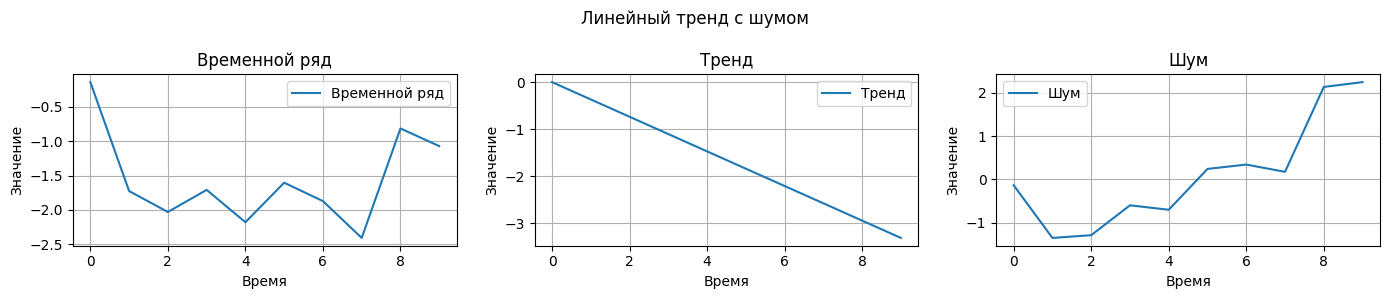

parameters of set 2
slope=0.3684210526315789
noise_level=0.8556565656565653



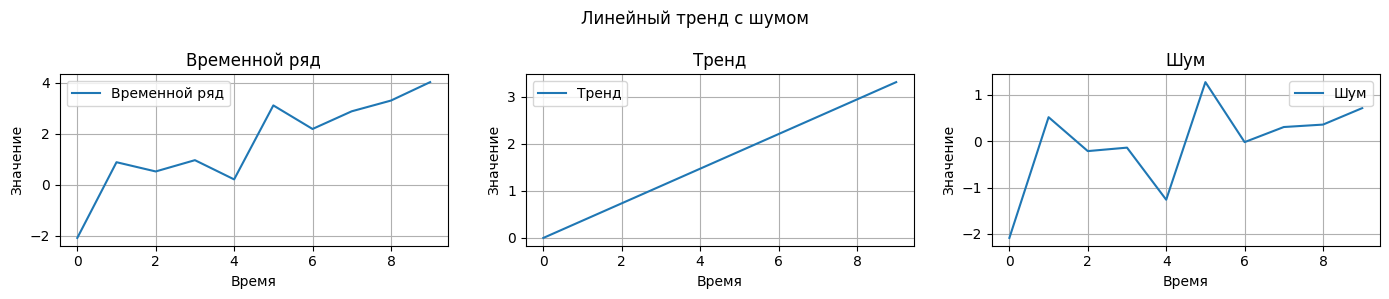

parameters of set 3
slope=0.15789473684210525
noise_level=1.0



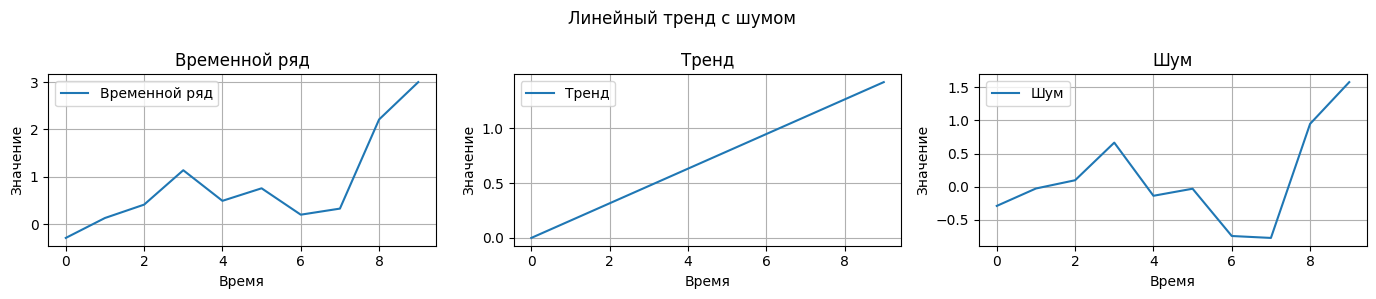

In [3]:
# задаем размер временного ряда
length = 10

# без доп параметров
ts_params_1 = linear_trend_params()
# ограничиваем коэффициент тренда интервалом [0,0.5]
ts_params_2 = linear_trend_params(slope_d=0, slope_up=0.5)
# ограничиваем уровень шума 1 стандартным отклонением
ts_params_3 = linear_trend_params(slope_d=0, slope_up=0.5, noise_d=1, noise_u=1)

for i, param in enumerate([ts_params_1, ts_params_2, ts_params_3]):
    print(f'parameters of set {i+1}')
    for k, v in param.items():
        print(f"{k}={v}")
    print()

    series, trend, noise = linear_trend(length = length, **param)
    vis.multi_plot_each(series_list=[series, trend, noise], labels=["Временной ряд", 'Тренд', 'Шум'], plot_title="Линейный тренд с шумом", xlabel="Время", ylabel="Значение", figsize=(14,3))


In [4]:
# можно создавать и более сложные данные
import json
from typing import List, Dict, Union
from core.generation.ts_generator import seasonal_series, seasonal_series_params, sawtooth_wave, sawtooth_wave_params, quadratic_trend, quadratic_trend_params, exponential_trend, exponential_trend_params, harmonic_oscillator, harmonic_oscillator_params, random_walk, random_walk_params

def generate_time_series(total_length: int, length: int, distributions: List[str], params_list: List[Dict], random_state: int = None) -> np.ndarray:
    """
    Генерирует временной ряд заданной длины, комбинируя временные ряды из одного или нескольких распределений.

    Параметры:
    - total_length: Общая длина временного ряда.
    - length: Длина каждого временного ряда, который будет использоваться для комбинирования.
    - distributions: Список строк, указывающих на типы распределений (например, ['linear', 'quadratic']).
    - params_list: Список словарей с параметрами для каждого распределения.
    - random_state: Seed для генерации случайных чисел.

    Возвращает:
    - Временной ряд (numpy array).
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    # Проверка на корректность входных данных
    if len(distributions) != len(params_list):
        raise ValueError("Количество распределений и параметров должно совпадать.")
    
    # Список для хранения сгенерированных временных рядов
    time_series_list = []
    params_info = []

    # Генерация временных рядов
    for dist, params in zip(distributions, params_list):
        if dist == 'linear':
            series, trend, noise = linear_trend(**params, length=length, random_state=random_state)
        elif dist == 'quadratic':
            series, trend, noise = quadratic_trend(**params, length=length, random_state=random_state)
        elif dist == 'exponential':
            series, trend, noise = exponential_trend(**params, length=length, random_state=random_state)
        elif dist == 'seasonal':
            series, seasonality, noise = seasonal_series(**params, length=length, random_state=random_state)
        elif dist == 'harmonic':
            series, oscillator, noise = harmonic_oscillator(**params, length=length, random_state=random_state)
        elif dist == 'sawtooth':
            series, sawtooth, noise = sawtooth_wave(**params, length=length, random_state=random_state)
        elif dist == 'random_walk':
            series, noise = random_walk(**params, length=length, random_state=random_state)
        else:
            raise ValueError(f"Неизвестное распределение: {dist}")
        
        time_series_list.append(series)
        params_info.append({'distribution': dist, 'params': params})

    # Комбинирование временных рядов
    combined_series = np.concatenate(time_series_list)[:total_length]

    # Сохранение параметров в JSON
    with open('time_series_params.json', 'w') as f:
        json.dump(params_info, f, indent=4)

    return combined_series

# Пример использования:
total_length = 100
length = 50
distributions = ['linear', 'quadratic']
params_list = [
    linear_trend_params(),
    quadratic_trend_params()
]

series = generate_time_series(total_length, length, distributions, params_list, random_state=42)
print(series)


ValueError: operands could not be broadcast together with shapes (10,) (50,) 

In [6]:
quadratic_trend_params()

{'a': array([-0.5       , -0.38888889, -0.27777778, -0.16666667, -0.05555556,
         0.05555556,  0.16666667,  0.27777778,  0.38888889,  0.5       ]),
 'b': 0.5555555555555554,
 'c': -0.11111111111111116,
 'noise_level': 5.858585858585859}

: 